In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [54]:
f = "spec17/544.nab_r/nab_aminos_trace.log.csv"
df = pd.read_csv(f)

In [55]:
# extract different datasets
no_rename = df[(df['Register Renaming'] == False) & (df['Memory Renaming'] == False)]
reg_rename = df[(df['Register Renaming'] == True) & (df['Memory Renaming'] == False)]
# mem_rename = df[(df['Register Renaming'] == False) & (df['Memory Renaming'] == True)]
# both_rename = df[(df['Register Renaming'] == True) & (df['Memory Renaming'] == True)]

In [56]:
num_instruction = df.get("Instructions")[0]
IPC = reg_rename.get("IPC").to_numpy()
widths = reg_rename.get("Width").to_numpy()
i = np.argmax(IPC)

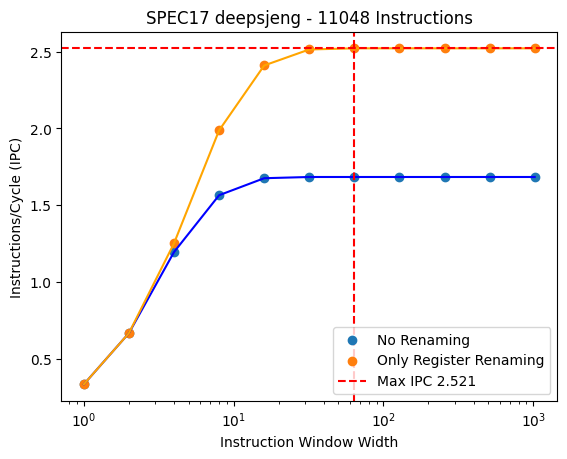

In [ ]:
plt.scatter(no_rename.get("Width"), no_rename.get("IPC"), label = "No Renaming")
plt.plot(no_rename.get("Width"), no_rename.get("IPC"), color = "blue")
plt.scatter(reg_rename.get("Width"), reg_rename.get("IPC"), label = "Only Register Renaming")
plt.plot(reg_rename.get("Width"), reg_rename.get("IPC"), color = "orange")
#plt.scatter(mem_rename.get("Width"), mem_rename.get("IPC"), label = "Only Memory Renaming")
#plt.scatter(mem_rename.get("Width"), mem_rename.get("IPC"), color = "green")
plt.title(f"SPEC17 nab - {num_instruction} Instructions")
#plt.scatter(both_rename.get("Width"), no_rename.get("IPC"), label = "Memory and Register Renaming
plt.xscale("log")
plt.axhline(y=IPC[i], color="r", linestyle = "--", label=f"Max IPC {np.round(IPC[i], 3)}")
plt.axvline(x=widths[i], color="r", linestyle="--")
plt.xlabel("Instruction Window Width")
plt.ylabel("Instructions/Cycle (IPC)")
plt.legend()